Comparison historical vs diffusion: wrong input

In [1]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fix for common Jupyter/Windows crash
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ==========================================
# 1. DATA COLLECTION & PREPARATION
# ==========================================
def get_dataset(filename='raw_macro_yield_dataset.csv'):
    df = pd.read_csv(filename, index_col=0)
    print("Loaded existing file.")
    print("Dataset shape:", df.shape)

    print("\nRow 0:")
    print(df.iloc[0])

    print("\nRow 1:")
    print(df.iloc[1])

    return df


def split_dataset(df, train_ratio=0.8):
    split_idx = int(len(df) * train_ratio)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    print("\nAfter split:")
    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)

    return train_df, test_df


class YieldDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.macro_cols = ['FedFunds', 'CPI', 'GDP']
        self.yield_cols = [c for c in df.columns if 'Y_DGS' in c]

        # Global normalization for yields
        self.mu_y = df[self.yield_cols].values.mean()
        self.std_y = df[self.yield_cols].values.std()

        # Column-wise normalization for macro variables
        self.mu_c = df[self.macro_cols].mean()
        self.std_c = df[self.macro_cols].std()

        y = (df[self.yield_cols].values - self.mu_y) / self.std_y
        c = (df[self.macro_cols].values - self.mu_c.values) / self.std_c.values

        self.yields = torch.tensor(y, dtype=torch.float32)
        self.macros = torch.tensor(c, dtype=torch.float32)

    def __len__(self):
        return len(self.yields)

    def __getitem__(self, idx):
        return self.yields[idx], self.macros[idx]


# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GroupNorm(8, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return x + self.net(x)


class CondResNet(nn.Module):
    def __init__(self, input_dim=11, cond_dim=3, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.macro_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(4)])
        self.final_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t, c):
        t_emb = self.time_mlp(t.float().unsqueeze(-1) / 1000.0)
        c_emb = self.macro_mlp(c)

        h = self.input_proj(x) + t_emb + c_emb
        for block in self.res_blocks:
            h = block(h)
        return self.final_proj(h)


# ==========================================
# 3. DIFFUSION ENGINE
# ==========================================
class DiffusionEngine:
    def __init__(self, model, T=300, device='cpu'):
        self.model = model
        self.T = T
        self.device = device

        self.beta = torch.linspace(1e-4, 0.02, T, device=device)
        self.alpha = 1.0 - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def train_loss(self, x0, c):
        x0 = x0.to(self.device)
        c = c.to(self.device)

        t = torch.randint(0, self.T, (x0.shape[0],), device=self.device)
        noise = torch.randn_like(x0)
        a_hat = self.alpha_hat[t].unsqueeze(-1)

        # Forward diffusion: add noise to clean yield curve
        xt = torch.sqrt(a_hat) * x0 + torch.sqrt(1 - a_hat) * noise

        # v-parameterization target
        v_target = torch.sqrt(a_hat) * noise - torch.sqrt(1 - a_hat) * x0
        v_pred = self.model(xt, t, c)

        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, c_scenario):
        c_scenario = c_scenario.to(self.device)
        n = c_scenario.shape[0]

        x = torch.randn((n, 11), device=self.device)

        for i in reversed(range(self.T)):
            t = torch.full((n,), i, dtype=torch.long, device=self.device)
            v = self.model(x, t, c_scenario)

            a_hat = self.alpha_hat[i]
            x0_recons = torch.sqrt(a_hat) * x - torch.sqrt(1 - a_hat) * v

            if i > 0:
                a_hat_prev = self.alpha_hat[i - 1]
                direction_xt = torch.sqrt(1 - a_hat_prev) * (
                    (x - torch.sqrt(a_hat) * x0_recons) / torch.sqrt(1 - a_hat)
                )
                x = torch.sqrt(a_hat_prev) * x0_recons + direction_xt
            else:
                x = x0_recons

        return x


# ==========================================
# 4. TRAINING FUNCTION
# ==========================================
def train_model(model, diffuser, loader, optimizer, epochs=100):
    print(f"Training on {len(loader.dataset)} samples...")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        batch_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for y, c in batch_bar:
            loss = diffuser.train_loss(y, c)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(loader)
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Avg loss: {avg_loss:.6f} | Elapsed: {elapsed:.1f}s")


# ==========================================
# 5. SYNTHETIC DATASET GENERATION
# ==========================================
def generate_synthetic_dataset(model, diffuser, dataset, scenarios_per_state=20,
                               chunk_size=500, output_file="synthetic_yield_curve_training_data.csv"):
    model.eval()

    all_macro_states = dataset.macros
    repeated_macros = all_macro_states.repeat_interleave(scenarios_per_state, dim=0)

    total_scenarios = len(repeated_macros)
    print(f"\nGenerating {total_scenarios} synthetic yield curves...")

    all_curves = []
    start_time = time.time()

    with torch.no_grad():
        chunk_bar = tqdm(range(0, total_scenarios, chunk_size), desc="Generating scenarios")
        for i in chunk_bar:
            chunk = repeated_macros[i:i + chunk_size]
            samples_norm = diffuser.sample(chunk)

            curves_chunk = (samples_norm.cpu().numpy() * dataset.std_y) + dataset.mu_y
            all_curves.append(curves_chunk)

            done = min(i + chunk_size, total_scenarios)
            elapsed = time.time() - start_time
            chunk_bar.set_postfix(done=f"{done}/{total_scenarios}", elapsed=f"{elapsed:.1f}s")

    final_curves = np.vstack(all_curves)
    macro_values = (repeated_macros.numpy() * dataset.std_c.values) + dataset.mu_c.values

    yield_columns = [
        'Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
        'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y'
    ]
    macro_columns = ['FedFunds', 'CPI', 'GDP']

    synthetic_df = pd.DataFrame(final_curves, columns=yield_columns)

    for i, col in enumerate(macro_columns):
        synthetic_df[col] = macro_values[:, i]

    # Save only generated scenarios, not historical yield curves
    synthetic_df['Scenario_ID'] = np.arange(len(synthetic_df))

    synthetic_df.to_csv(output_file, index=False)

    print(f"Synthetic dataset saved to: {output_file}")
    print(f"Macro states used from training set: {len(dataset)}")
    print(f"Scenarios per state: {scenarios_per_state}")
    print(f"Total synthetic yield curves: {len(synthetic_df)}")

    return synthetic_df, final_curves


# ==========================================
# 6. VALIDATION PLOT
# ==========================================
def plot_generated_curves(final_curves, max_curves_to_plot=500):
    plt.figure(figsize=(12, 7))
    maturities = [1/12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]

    n_plot = min(len(final_curves), max_curves_to_plot)

    for i in range(n_plot):
        plt.plot(maturities, final_curves[i], alpha=0.05)

    plt.plot(
        maturities,
        final_curves[:n_plot].mean(axis=0),
        linewidth=3,
        label='Average Synthetic Yield Curve'
    )

    plt.title(f"Distribution of {n_plot} Synthetic Yield Curves")
    plt.xlabel("Maturity (Years)")
    plt.ylabel("Yield (%)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Step 1: read raw dataset
    raw_df = get_dataset('raw_data.csv')

    # Step 2: split train/test
    train_df, test_df = split_dataset(raw_df, train_ratio=0.8)

    # Optional: save split datasets
    train_df.to_csv("train_data.csv")
    test_df.to_csv("test_data.csv")
    print("\nSaved train_data.csv and test_data.csv")

    # Step 3: train only on training data
    train_dataset = YieldDataset(train_df)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

    model = CondResNet().to(device)
    diffuser = DiffusionEngine(model, T=300, device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    train_model(model, diffuser, train_loader, optimizer, epochs=101)

    # Step 4: generate synthetic scenarios from training macro states
    synthetic_df, final_curves = generate_synthetic_dataset(
        model=model,
        diffuser=diffuser,
        dataset=train_dataset,
        scenarios_per_state=20,
        chunk_size=500,
        output_file="correctsplit_synthetic_yield_curve_training_data.csv"
    )

    print("\nFinished training and synthetic data generation.")
    print("Next step: compute metrics, then visualize generated scenarios.")

Using device: cpu
Loaded existing file.
Dataset shape: (6037, 14)

Row 0:
FedFunds        1.730
CPI           177.700
GDP         14372.785
Y_DGS1MO        1.730
Y_DGS3MO        1.740
Y_DGS6MO        1.850
Y_DGS1          2.280
Y_DGS2          3.220
Y_DGS3          3.750
Y_DGS5          4.520
Y_DGS7          4.970
Y_DGS10         5.200
Y_DGS20         5.860
Y_DGS30         5.560
Name: 2002-01-02, dtype: float64

Row 1:
FedFunds        1.730
CPI           177.700
GDP         14372.785
Y_DGS1MO        1.730
Y_DGS3MO        1.730
Y_DGS6MO        1.820
Y_DGS1          2.240
Y_DGS2          3.190
Y_DGS3          3.710
Y_DGS5          4.480
Y_DGS7          4.930
Y_DGS10         5.160
Y_DGS20         5.830
Y_DGS30         5.540
Name: 2002-01-03, dtype: float64

After split:
Train shape: (4829, 14)
Test shape: (1208, 14)

Saved train_data.csv and test_data.csv
Training on 4829 samples...


Epoch 1/101 | Avg loss: 0.361869 | Elapsed: 4.5s


Epoch 2/101 | Avg loss: 0.226263 | Elapsed: 8.9s


Epoch 57/101 | Avg loss: 0.083050 | Elapsed: 270.5s


Epoch 58/101 | Avg loss: 0.082584 | Elapsed: 275.2s


...

Epoch 99/101 | Avg loss: 0.071218 | Elapsed: 462.8s


Epoch 100/101 | Avg loss: 0.069919 | Elapsed: 467.5s


Epoch 101/101 | Avg loss: 0.066474 | Elapsed: 472.4s

Generating 96580 synthetic yield curves...


Generating scenarios: 100%|██████████| 194/194 [13:53<00:00,  4.30s/it, done=96580/96580, elapsed=833.5s]


Synthetic dataset saved to: synthetic_yield_curve_training_data.csv
Macro states used from training set: 4829
Scenarios per state: 20
Total synthetic yield curves: 96580

Finished training and synthetic data generation.
Next step: compute metrics, then visualize generated scenarios.


Dataset shape: (96580, 11)

Percentage variance explained
PC1    0.833445
PC2    0.155091
PC3    0.007851
dtype: float64

Cumulative variance explained (first 3 PCs)
0.9963876518928565


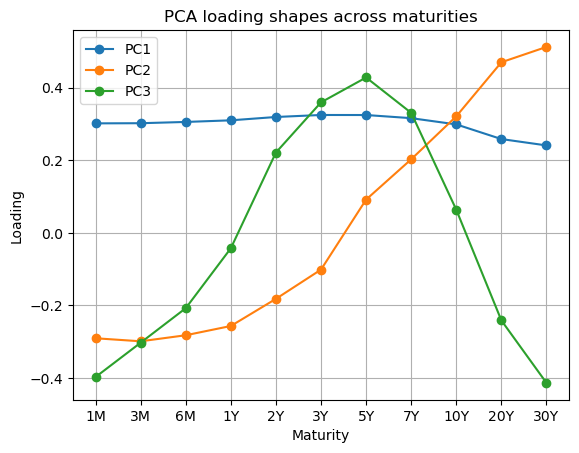

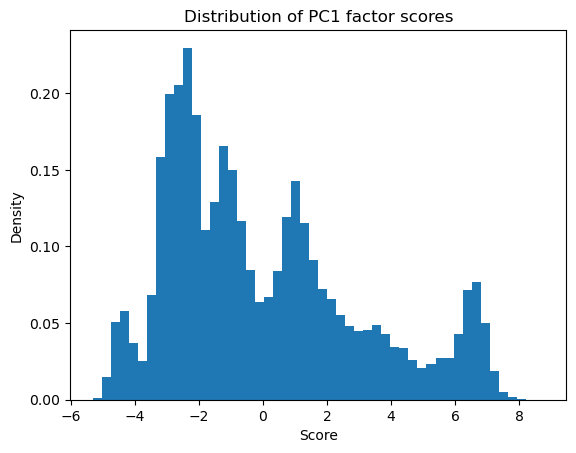

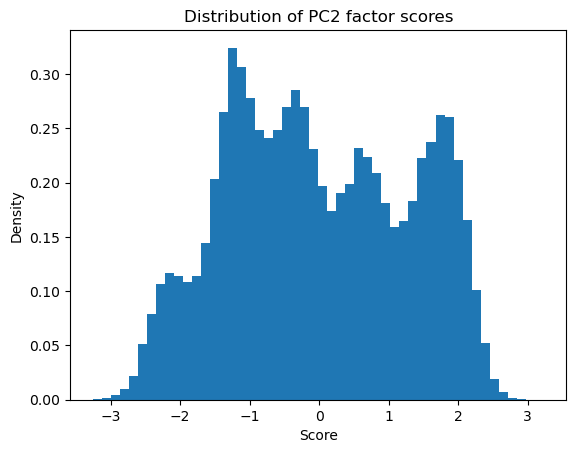

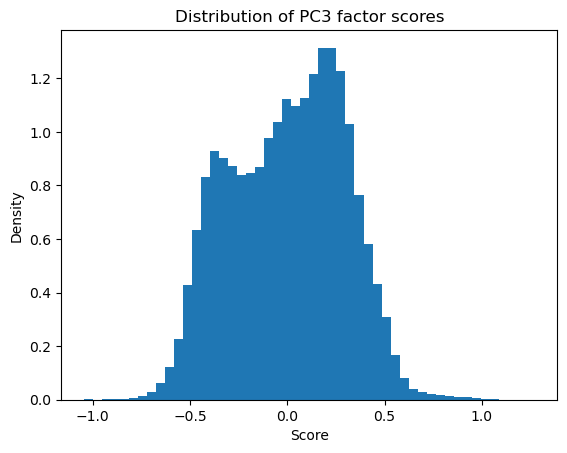


Factor score statistics
                PC1           PC2           PC3
count  9.658000e+04  9.658000e+04  9.658000e+04
mean  -3.766803e-17  7.533607e-17  4.340652e-17
std    3.027853e+00  1.306141e+00  2.938811e-01
min   -5.305813e+00 -3.255525e+00 -1.045865e+00
25%   -2.395439e+00 -1.069666e+00 -2.401944e-01
50%   -8.279779e-01 -1.213981e-01  2.161876e-02
75%    1.707051e+00  1.131786e+00  2.297174e-01
max    8.763063e+00  3.230198e+00  1.272582e+00

Correlation among factor scores
              PC1           PC2           PC3
PC1  1.000000e+00  7.575788e-16 -1.803814e-15
PC2  7.575788e-16  1.000000e+00 -3.149087e-15
PC3 -1.803814e-15 -3.149087e-15  1.000000e+00

Volatility term structure
Yield_1M     1.418029
Yield_3M     1.461118
Yield_6M     1.516279
Yield_1Y     1.449844
Yield_2Y     1.375761
Yield_3Y     1.311287
Yield_5Y     1.160092
Yield_7Y     1.103213
Yield_10Y    1.055560
Yield_20Y    1.104227
Yield_30Y    1.025067
dtype: float64


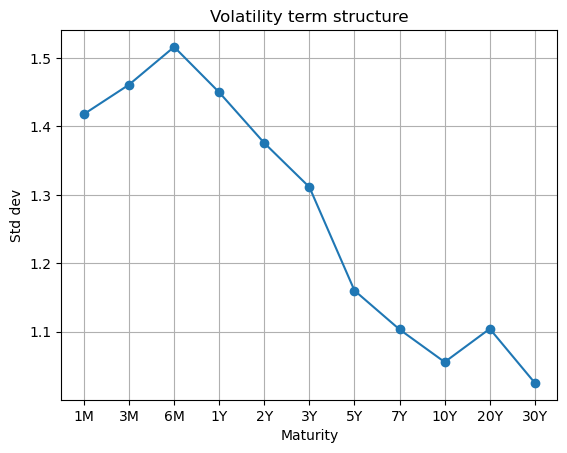


Cross maturity correlation matrix
           Yield_1M  Yield_3M  Yield_6M  Yield_1Y  Yield_2Y  Yield_3Y  \
Yield_1M   1.000000  0.996223  0.990392  0.983050  0.964491  0.937509   
Yield_3M   0.996223  1.000000  0.996378  0.990757  0.971317  0.942502   
Yield_6M   0.990392  0.996378  1.000000  0.996474  0.979557  0.952581   
Yield_1Y   0.983050  0.990757  0.996474  1.000000  0.989362  0.967226   
Yield_2Y   0.964491  0.971317  0.979557  0.989362  1.000000  0.991550   
Yield_3Y   0.937509  0.942502  0.952581  0.967226  0.991550  1.000000   
Yield_5Y   0.841293  0.843282  0.858159  0.880615  0.929729  0.964819   
Yield_7Y   0.766068  0.765472  0.782323  0.807416  0.867180  0.916022   
Yield_10Y  0.665954  0.663465  0.683336  0.710164  0.775951  0.835547   
Yield_20Y  0.489153  0.482583  0.503480  0.531728  0.607658  0.681995   
Yield_30Y  0.426521  0.416860  0.435750  0.462756  0.540558  0.618472   

           Yield_5Y  Yield_7Y  Yield_10Y  Yield_20Y  Yield_30Y  
Yield_1M   0.841293  0.

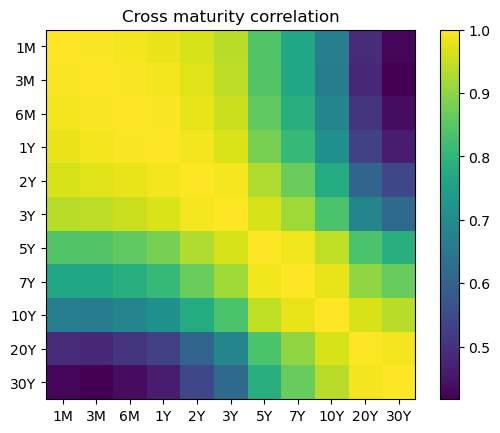


Lag-1 autocorrelation
Yield_1M     0.986516
Yield_3M     0.990859
Yield_6M     0.993115
Yield_1Y     0.990749
Yield_2Y     0.984008
Yield_3Y     0.977138
Yield_5Y     0.961684
Yield_7Y     0.956984
Yield_10Y    0.956105
Yield_20Y    0.961199
Yield_30Y    0.959551
dtype: float64


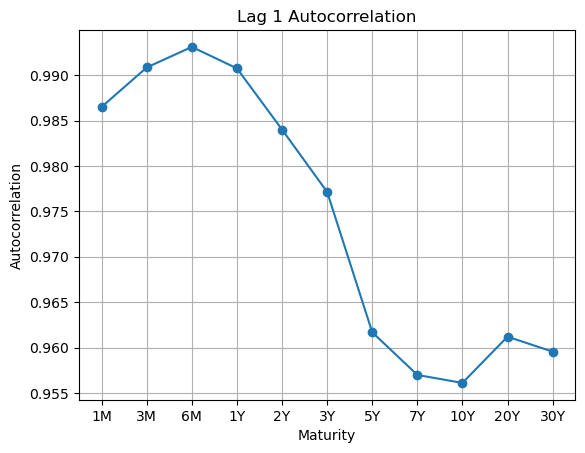


Wasserstein distance between scenario groups
PC1    0.474677
PC2    0.298262
PC3    0.457332
dtype: float64
Average Wasserstein distance: 0.41009015987032504


In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance


# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv("correctsplit_synthetic_yield_curve_training_data.csv")

yield_cols = [
    "Yield_1M","Yield_3M","Yield_6M","Yield_1Y","Yield_2Y",
    "Yield_3Y","Yield_5Y","Yield_7Y","Yield_10Y","Yield_20Y","Yield_30Y"
]

maturity_labels = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]

yields = data[yield_cols].dropna()

print("Dataset shape:", yields.shape)


# ============================================================
# A. PCA ANALYSIS
# ============================================================

# standardize
z = (yields - yields.mean()) / yields.std()

pca = PCA(n_components=3)
scores = pca.fit_transform(z)

scores = pd.DataFrame(scores, columns=["PC1","PC2","PC3"])

explained_variance = pca.explained_variance_ratio_

print("\nPercentage variance explained")
print(pd.Series(explained_variance, index=["PC1","PC2","PC3"]))

print("\nCumulative variance explained (first 3 PCs)")
print(explained_variance.sum())


# ============================================================
# PCA LOADING SHAPES
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=yield_cols,
    columns=["PC1","PC2","PC3"]
)

plt.figure()
for pc in loadings.columns:
    plt.plot(maturity_labels, loadings[pc], marker='o', label=pc)

plt.title("PCA loading shapes across maturities")
plt.xlabel("Maturity")
plt.ylabel("Loading")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# DISTRIBUTION OF FACTOR SCORES
# ============================================================

for pc in ["PC1","PC2","PC3"]:
    plt.figure()
    plt.hist(scores[pc], bins=50, density=True)
    plt.title(f"Distribution of {pc} factor scores")
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.show()


print("\nFactor score statistics")
print(scores.describe())


# ============================================================
# CORRELATION STRUCTURE AMONG FACTOR SCORES
# ============================================================

score_corr = scores.corr()

print("\nCorrelation among factor scores")
print(score_corr)


# ============================================================
# B. VOLATILITY TERM STRUCTURE
# ============================================================

volatility = yields.std()

print("\nVolatility term structure")
print(volatility)

plt.figure()
plt.plot(maturity_labels, volatility.values, marker='o')
plt.title("Volatility term structure")
plt.xlabel("Maturity")
plt.ylabel("Std dev")
plt.grid()
plt.show()


# ============================================================
# C. CROSS MATURITY CORRELATION
# ============================================================

cross_corr = yields.corr()

print("\nCross maturity correlation matrix")
print(cross_corr)

plt.figure()
plt.imshow(cross_corr)
plt.colorbar()
plt.title("Cross maturity correlation")
plt.xticks(range(len(maturity_labels)), maturity_labels)
plt.yticks(range(len(maturity_labels)), maturity_labels)
plt.show()


# ============================================================
# D. AUTOCORRELATION (Lag 1)
# ============================================================

autocorr = {}

for col in yield_cols:
    autocorr[col] = yields[col].autocorr(lag=1)

autocorr = pd.Series(autocorr)

print("\nLag-1 autocorrelation")
print(autocorr)

plt.figure()
plt.plot(maturity_labels, autocorr.values, marker='o')
plt.title("Lag 1 Autocorrelation")
plt.xlabel("Maturity")
plt.ylabel("Autocorrelation")
plt.grid()
plt.show()


# ============================================================
# E. WASSERSTEIN DISTANCE IN PCA SPACE
# Compare scenario groups
# ============================================================

if "Scenario_ID" in data.columns:

    scenarios = data["Scenario_ID"].unique()

    if len(scenarios) >= 2:

        s1 = scores[data["Scenario_ID"] == scenarios[0]]
        s2 = scores[data["Scenario_ID"] == scenarios[1]]

        wasserstein = {
            "PC1": wasserstein_distance(s1["PC1"], s2["PC1"]),
            "PC2": wasserstein_distance(s1["PC2"], s2["PC2"]),
            "PC3": wasserstein_distance(s1["PC3"], s2["PC3"]),
        }

        print("\nWasserstein distance between scenario groups")
        print(pd.Series(wasserstein))

        print("Average Wasserstein distance:", np.mean(list(wasserstein.values())))


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from matplotlib.backends.backend_pdf import PdfPages


# ============================================================
# CONFIG
# ============================================================

synthetic_file = "correctsplit_synthetic_yield_curve_training_data.csv"
historical_file = "raw_macro_yield_train.csv"
output_dir = "yield_curve_analysis_output"
output_pdf = os.path.join(output_dir, "synthetic_vs_historical_report.pdf")

yield_cols = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y"
]

maturity_labels = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def add_text_page(pdf, title, lines, fontsize=10, lines_per_page=35):
    """
    Add one or more text pages to the PDF.
    """
    chunks = [lines[i:i + lines_per_page] for i in range(0, len(lines), lines_per_page)]
    if not chunks:
        chunks = [[]]

    for page_num, chunk in enumerate(chunks, start=1):
        fig = plt.figure(figsize=(11, 8.5))
        plt.axis("off")

        full_title = title if len(chunks) == 1 else f"{title} (page {page_num})"
        plt.text(0.01, 0.97, full_title, fontsize=14, fontweight="bold", va="top", ha="left")

        y = 0.92
        for line in chunk:
            plt.text(0.01, y, line, fontsize=fontsize, family="monospace", va="top", ha="left")
            y -= 0.025

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)


def series_to_lines(title, s, float_fmt="{:,.6f}"):
    lines = [title, "-" * len(title)]
    for idx, val in s.items():
        if pd.isna(val):
            lines.append(f"{idx:<20} NaN")
        else:
            lines.append(f"{idx:<20} {float_fmt.format(val)}")
    return lines


def df_to_lines(title, df, float_fmt="{:,.6f}"):
    lines = [title, "-" * len(title)]
    lines.append(df.to_string(float_format=lambda x: float_fmt.format(x)))
    return lines


def plot_and_save(pdf, fig):
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def analyze_dataset(
    data: pd.DataFrame,
    dataset_name: str,
    yield_cols: list,
    maturity_labels: list
):
    """
    Compute the same metrics as your original code for one dataset.
    Returns a dictionary of results.
    """
    yields = data[yield_cols].dropna().copy()

    # PCA on this dataset alone
    z = (yields - yields.mean()) / yields.std(ddof=1)
    pca = PCA(n_components=3)
    scores_array = pca.fit_transform(z)

    scores = pd.DataFrame(scores_array, columns=["PC1", "PC2", "PC3"], index=yields.index)

    explained_variance = pd.Series(
        pca.explained_variance_ratio_,
        index=["PC1", "PC2", "PC3"],
        name=f"{dataset_name}_explained_variance"
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=yield_cols,
        columns=["PC1", "PC2", "PC3"]
    )

    score_corr = scores.corr()
    volatility = yields.std(ddof=1)
    cross_corr = yields.corr()

    autocorr = pd.Series(
        {col: yields[col].autocorr(lag=1) for col in yield_cols},
        name=f"{dataset_name}_lag1_autocorr"
    )

    # Scenario Wasserstein inside this dataset, if available
    scenario_wasserstein = None
    if "Scenario_ID" in data.columns:
        scenario_subset = data.loc[yields.index, "Scenario_ID"]
        scenarios = scenario_subset.dropna().unique()

        if len(scenarios) >= 2:
            s1 = scores.loc[scenario_subset == scenarios[0]]
            s2 = scores.loc[scenario_subset == scenarios[1]]

            if len(s1) > 0 and len(s2) > 0:
                scenario_wasserstein = pd.Series({
                    "PC1": wasserstein_distance(s1["PC1"], s2["PC1"]),
                    "PC2": wasserstein_distance(s1["PC2"], s2["PC2"]),
                    "PC3": wasserstein_distance(s1["PC3"], s2["PC3"]),
                    "Average": np.mean([
                        wasserstein_distance(s1["PC1"], s2["PC1"]),
                        wasserstein_distance(s1["PC2"], s2["PC2"]),
                        wasserstein_distance(s1["PC3"], s2["PC3"]),
                    ])
                }, name=f"{dataset_name}_scenario_wasserstein")

    return {
        "dataset_name": dataset_name,
        "raw_data": data,
        "yields": yields,
        "z": z,
        "pca_model": pca,
        "scores": scores,
        "explained_variance": explained_variance,
        "cumulative_variance_3pc": explained_variance.sum(),
        "loadings": loadings,
        "score_corr": score_corr,
        "volatility": volatility,
        "cross_corr": cross_corr,
        "autocorr": autocorr,
        "scenario_wasserstein": scenario_wasserstein
    }


def compare_datasets(hist_results, synth_results, yield_cols):
    """
    Compare historical and synthetic datasets directly.
    Uses historical scaler + historical PCA as the common factor basis.
    """
    hist_y = hist_results["yields"].copy()
    synth_y = synth_results["yields"].copy()

    # Align on common columns only
    hist_y = hist_y[yield_cols]
    synth_y = synth_y[yield_cols]

    # Shared PCA basis: fit on historical, project both
    scaler = StandardScaler()
    hist_z_shared = scaler.fit_transform(hist_y)
    synth_z_shared = scaler.transform(synth_y)

    shared_pca = PCA(n_components=3)
    hist_scores_shared = pd.DataFrame(
        shared_pca.fit_transform(hist_z_shared),
        columns=["PC1", "PC2", "PC3"]
    )
    synth_scores_shared = pd.DataFrame(
        shared_pca.transform(synth_z_shared),
        columns=["PC1", "PC2", "PC3"]
    )

    shared_loadings = pd.DataFrame(
        shared_pca.components_.T,
        index=yield_cols,
        columns=["PC1", "PC2", "PC3"]
    )

    # Metric comparison tables
    explained_comparison = pd.DataFrame({
        "Historical": hist_results["explained_variance"],
        "Synthetic": synth_results["explained_variance"]
    })
    explained_comparison["Difference"] = explained_comparison["Synthetic"] - explained_comparison["Historical"]

    volatility_comparison = pd.DataFrame({
        "Historical": hist_results["volatility"],
        "Synthetic": synth_results["volatility"]
    })
    volatility_comparison["Difference"] = volatility_comparison["Synthetic"] - volatility_comparison["Historical"]
    volatility_comparison["Abs_Difference"] = volatility_comparison["Difference"].abs()

    autocorr_comparison = pd.DataFrame({
        "Historical": hist_results["autocorr"],
        "Synthetic": synth_results["autocorr"]
    })
    autocorr_comparison["Difference"] = autocorr_comparison["Synthetic"] - autocorr_comparison["Historical"]
    autocorr_comparison["Abs_Difference"] = autocorr_comparison["Difference"].abs()

    # Wasserstein distances in common PCA space
    cross_dataset_wasserstein = pd.Series({
        "PC1": wasserstein_distance(hist_scores_shared["PC1"], synth_scores_shared["PC1"]),
        "PC2": wasserstein_distance(hist_scores_shared["PC2"], synth_scores_shared["PC2"]),
        "PC3": wasserstein_distance(hist_scores_shared["PC3"], synth_scores_shared["PC3"]),
    }, name="Historical_vs_Synthetic_Wasserstein")
    cross_dataset_wasserstein.loc["Average"] = cross_dataset_wasserstein.mean()

    # Correlation matrix difference
    corr_diff = synth_results["cross_corr"] - hist_results["cross_corr"]

    return {
        "shared_scaler": scaler,
        "shared_pca": shared_pca,
        "shared_loadings": shared_loadings,
        "hist_scores_shared": hist_scores_shared,
        "synth_scores_shared": synth_scores_shared,
        "explained_comparison": explained_comparison,
        "volatility_comparison": volatility_comparison,
        "autocorr_comparison": autocorr_comparison,
        "cross_dataset_wasserstein": cross_dataset_wasserstein,
        "corr_diff": corr_diff
    }


def save_results_to_csv(hist_results, synth_results, comparison, output_dir):
    """
    Save all important tables as CSV files.
    """
    # Historical
    hist_results["explained_variance"].to_csv(os.path.join(output_dir, "historical_explained_variance.csv"))
    hist_results["loadings"].to_csv(os.path.join(output_dir, "historical_pca_loadings.csv"))
    hist_results["scores"].describe().to_csv(os.path.join(output_dir, "historical_score_statistics.csv"))
    hist_results["score_corr"].to_csv(os.path.join(output_dir, "historical_score_correlation.csv"))
    hist_results["volatility"].to_csv(os.path.join(output_dir, "historical_volatility.csv"))
    hist_results["cross_corr"].to_csv(os.path.join(output_dir, "historical_cross_maturity_correlation.csv"))
    hist_results["autocorr"].to_csv(os.path.join(output_dir, "historical_lag1_autocorrelation.csv"))

    if hist_results["scenario_wasserstein"] is not None:
        hist_results["scenario_wasserstein"].to_csv(os.path.join(output_dir, "historical_scenario_wasserstein.csv"))

    # Synthetic
    synth_results["explained_variance"].to_csv(os.path.join(output_dir, "synthetic_explained_variance.csv"))
    synth_results["loadings"].to_csv(os.path.join(output_dir, "synthetic_pca_loadings.csv"))
    synth_results["scores"].describe().to_csv(os.path.join(output_dir, "synthetic_score_statistics.csv"))
    synth_results["score_corr"].to_csv(os.path.join(output_dir, "synthetic_score_correlation.csv"))
    synth_results["volatility"].to_csv(os.path.join(output_dir, "synthetic_volatility.csv"))
    synth_results["cross_corr"].to_csv(os.path.join(output_dir, "synthetic_cross_maturity_correlation.csv"))
    synth_results["autocorr"].to_csv(os.path.join(output_dir, "synthetic_lag1_autocorrelation.csv"))

    if synth_results["scenario_wasserstein"] is not None:
        synth_results["scenario_wasserstein"].to_csv(os.path.join(output_dir, "synthetic_scenario_wasserstein.csv"))

    # Comparison
    comparison["shared_loadings"].to_csv(os.path.join(output_dir, "shared_pca_loadings_historical_basis.csv"))
    comparison["explained_comparison"].to_csv(os.path.join(output_dir, "explained_variance_comparison.csv"))
    comparison["volatility_comparison"].to_csv(os.path.join(output_dir, "volatility_comparison.csv"))
    comparison["autocorr_comparison"].to_csv(os.path.join(output_dir, "autocorrelation_comparison.csv"))
    comparison["cross_dataset_wasserstein"].to_csv(os.path.join(output_dir, "cross_dataset_wasserstein.csv"))
    comparison["corr_diff"].to_csv(os.path.join(output_dir, "cross_maturity_correlation_difference.csv"))


def generate_pdf_report(hist_results, synth_results, comparison, maturity_labels, output_pdf):
    with PdfPages(output_pdf) as pdf:
        # ----------------------------------------------------
        # COVER / SUMMARY PAGE
        # ----------------------------------------------------
        summary_lines = [
            "Synthetic vs Historical Yield Curve Analysis Report",
            "",
            f"Historical observations: {hist_results['yields'].shape[0]}",
            f"Synthetic observations:  {synth_results['yields'].shape[0]}",
            f"Number of maturities:    {hist_results['yields'].shape[1]}",
            "",
            "This report contains:",
            "1. Dataset-level PCA diagnostics for historical and synthetic data separately",
            "2. Volatility, cross-maturity correlation, and lag-1 autocorrelation",
            "3. Synthetic vs historical comparison tables",
            "4. Shared-PCA comparison where historical PCA is used as the common basis",
            "5. Wasserstein distances between historical and synthetic factor score distributions",
            "",
            "Important note:",
            "Direct PCA score comparison should use a common PCA basis.",
            "This report therefore includes a shared PCA fitted on historical data only.",
        ]
        add_text_page(pdf, "Report Summary", summary_lines, fontsize=11)

        # ----------------------------------------------------
        # TEXT TABLES
        # ----------------------------------------------------
        add_text_page(
            pdf,
            "Explained Variance Comparison",
            df_to_lines("Explained Variance Comparison", comparison["explained_comparison"])
        )

        add_text_page(
            pdf,
            "Historical Score Statistics",
            df_to_lines("Historical Score Statistics", hist_results["scores"].describe())
        )

        add_text_page(
            pdf,
            "Synthetic Score Statistics",
            df_to_lines("Synthetic Score Statistics", synth_results["scores"].describe())
        )

        add_text_page(
            pdf,
            "Historical Factor Score Correlation",
            df_to_lines("Historical Factor Score Correlation", hist_results["score_corr"])
        )

        add_text_page(
            pdf,
            "Synthetic Factor Score Correlation",
            df_to_lines("Synthetic Factor Score Correlation", synth_results["score_corr"])
        )

        add_text_page(
            pdf,
            "Volatility Comparison",
            df_to_lines("Volatility Comparison", comparison["volatility_comparison"])
        )

        add_text_page(
            pdf,
            "Autocorrelation Comparison",
            df_to_lines("Autocorrelation Comparison", comparison["autocorr_comparison"])
        )

        add_text_page(
            pdf,
            "Cross-Dataset Wasserstein Distances (Shared Historical PCA Basis)",
            series_to_lines(
                "Cross-Dataset Wasserstein Distances (Shared Historical PCA Basis)",
                comparison["cross_dataset_wasserstein"]
            )
        )

        if hist_results["scenario_wasserstein"] is not None:
            add_text_page(
                pdf,
                "Historical Scenario Wasserstein",
                series_to_lines("Historical Scenario Wasserstein", hist_results["scenario_wasserstein"])
            )

        if synth_results["scenario_wasserstein"] is not None:
            add_text_page(
                pdf,
                "Synthetic Scenario Wasserstein",
                series_to_lines("Synthetic Scenario Wasserstein", synth_results["scenario_wasserstein"])
            )

        # ----------------------------------------------------
        # PLOT 1: PCA loadings (historical vs synthetic)
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        for pc in ["PC1", "PC2", "PC3"]:
            plt.plot(maturity_labels, hist_results["loadings"][pc], marker="o", label=f"Historical {pc}")
            plt.plot(maturity_labels, synth_results["loadings"][pc], marker="x", linestyle="--", label=f"Synthetic {pc}")
        plt.title("PCA Loading Shapes Across Maturities")
        plt.xlabel("Maturity")
        plt.ylabel("Loading")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 2: Shared historical-basis loadings
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        for pc in ["PC1", "PC2", "PC3"]:
            plt.plot(maturity_labels, comparison["shared_loadings"][pc], marker="o", label=pc)
        plt.title("Shared PCA Loadings (Historical Basis)")
        plt.xlabel("Maturity")
        plt.ylabel("Loading")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 3-5: factor score distributions in shared basis
        # ----------------------------------------------------
        for pc in ["PC1", "PC2", "PC3"]:
            fig = plt.figure(figsize=(10, 6))
            plt.hist(comparison["hist_scores_shared"][pc], bins=50, density=True, alpha=0.6, label="Historical")
            plt.hist(comparison["synth_scores_shared"][pc], bins=50, density=True, alpha=0.6, label="Synthetic")
            plt.title(f"{pc} Score Distribution (Shared Historical PCA Basis)")
            plt.xlabel("Score")
            plt.ylabel("Density")
            plt.legend()
            plt.grid(True)
            plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 6: Volatility comparison
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, hist_results["volatility"].values, marker="o", label="Historical")
        plt.plot(maturity_labels, synth_results["volatility"].values, marker="x", linestyle="--", label="Synthetic")
        plt.title("Volatility Term Structure")
        plt.xlabel("Maturity")
        plt.ylabel("Std Dev")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 7: Volatility absolute difference
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, comparison["volatility_comparison"]["Abs_Difference"].values, marker="o")
        plt.title("Absolute Volatility Difference |Synthetic - Historical|")
        plt.xlabel("Maturity")
        plt.ylabel("Absolute Difference")
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 8: Lag-1 autocorrelation comparison
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, hist_results["autocorr"].values, marker="o", label="Historical")
        plt.plot(maturity_labels, synth_results["autocorr"].values, marker="x", linestyle="--", label="Synthetic")
        plt.title("Lag-1 Autocorrelation")
        plt.xlabel("Maturity")
        plt.ylabel("Autocorrelation")
        plt.legend()
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 9: Autocorrelation absolute difference
        # ----------------------------------------------------
        fig = plt.figure(figsize=(10, 6))
        plt.plot(maturity_labels, comparison["autocorr_comparison"]["Abs_Difference"].values, marker="o")
        plt.title("Absolute Lag-1 Autocorrelation Difference |Synthetic - Historical|")
        plt.xlabel("Maturity")
        plt.ylabel("Absolute Difference")
        plt.grid(True)
        plot_and_save(pdf, fig)

        # ----------------------------------------------------
        # PLOT 10-12: Correlation heatmaps
        # ----------------------------------------------------
        for title, corr_df in [
            ("Historical Cross-Maturity Correlation", hist_results["cross_corr"]),
            ("Synthetic Cross-Maturity Correlation", synth_results["cross_corr"]),
            ("Correlation Difference (Synthetic - Historical)", comparison["corr_diff"]),
        ]:
            fig = plt.figure(figsize=(8, 7))
            plt.imshow(corr_df, aspect="auto")
            plt.colorbar()
            plt.title(title)
            plt.xticks(range(len(maturity_labels)), maturity_labels)
            plt.yticks(range(len(maturity_labels)), maturity_labels)
            plot_and_save(pdf, fig)


# ============================================================
# MAIN
# ============================================================

# Load datasets
synthetic_data = pd.read_csv(synthetic_file)
historical_data = pd.read_csv(historical_file)

# Basic column check
missing_synth = [c for c in yield_cols if c not in synthetic_data.columns]
missing_hist = [c for c in yield_cols if c not in historical_data.columns]

if missing_synth:
    raise ValueError(f"Synthetic dataset is missing columns: {missing_synth}")

if missing_hist:
    raise ValueError(f"Historical dataset is missing columns: {missing_hist}")

# Analyze each dataset
synthetic_results = analyze_dataset(
    data=synthetic_data,
    dataset_name="Synthetic",
    yield_cols=yield_cols,
    maturity_labels=maturity_labels
)

historical_results = analyze_dataset(
    data=historical_data,
    dataset_name="Historical",
    yield_cols=yield_cols,
    maturity_labels=maturity_labels
)

# Compare
comparison_results = compare_datasets(
    hist_results=historical_results,
    synth_results=synthetic_results,
    yield_cols=yield_cols
)

# Save CSV outputs
save_results_to_csv(
    hist_results=historical_results,
    synth_results=synthetic_results,
    comparison=comparison_results,
    output_dir=output_dir
)

# Save PDF report
generate_pdf_report(
    hist_results=historical_results,
    synth_results=synthetic_results,
    comparison=comparison_results,
    maturity_labels=maturity_labels,
    output_pdf=output_pdf
)

# Console summary
print("========================================")
print("ANALYSIS COMPLETE")
print("========================================")
print(f"Historical shape: {historical_results['yields'].shape}")
print(f"Synthetic shape:  {synthetic_results['yields'].shape}")
print("")
print("Explained variance comparison:")
print(comparison_results["explained_comparison"])
print("")
print("Cross-dataset Wasserstein distances (shared historical PCA basis):")
print(comparison_results["cross_dataset_wasserstein"])
print("")
print(f"PDF report saved to: {output_pdf}")
print(f"CSV files saved in:  {output_dir}")

ANALYSIS COMPLETE
Historical shape: (4836, 11)
Synthetic shape:  (96580, 11)

Explained variance comparison:
     Historical  Synthetic  Difference
PC1    0.841005   0.833445   -0.007560
PC2    0.148156   0.155091    0.006935
PC3    0.008618   0.007851   -0.000767

Cross-dataset Wasserstein distances (shared historical PCA basis):
PC1        0.168215
PC2        0.079904
PC3        0.023988
Average    0.090702
Name: Historical_vs_Synthetic_Wasserstein, dtype: float64

PDF report saved to: yield_curve_analysis_output\synthetic_vs_historical_report.pdf
CSV files saved in:  yield_curve_analysis_output
